# Pumpkin-Spice-Season 🎃
### The PSL launches in late August — so does Starbucks beat the market into the fall?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pumpkin premium?: Busted](https://img.shields.io/badge/Pumpkin_premium%3F-Busted-8b949e?style=flat-square)

It's the most reliable ritual in American retail: every late August, Starbucks brings back the Pumpkin Spice Latte, the internet loses its mind, and "pumpkin spice season" runs from the PSL launch through Thanksgiving. Surely all that autumn foot-traffic shows up in the stock — buy SBUX in August, ride the pumpkin-spice quarter, beat the market? We checked 33 years of Starbucks returns *relative to the S&P 500*. The answer is no — and the way it fails is a little lesson in how a great stock fools you into seeing a calendar.

> **Plain-language layer.** The HAC t-stats, the window placebo and the rotation math are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Not investment advice. Every chart is generated by the code beside it; the cell banners say whether it is the real SBUX/SPY tape or the offline synthetic control.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (pumpkin_spice_season/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from pumpkin_spice_season import data, strategy as st

# Cache-first real tape; fall back to the synthetic control OFFLINE and banner which tape we show.
try:
    from quantlab import repro
    d = repro.as_of(data.fetch_data())   # cache-first (examples/verify.py --fetch)
    if d.empty:
        raise RuntimeError("cache miss")
    TAPE = "REAL  (SBUX/SPY total-return monthly, 1993-02..2026-05, 400 months, fp 1d50b4e1e153)"
except Exception as e:
    d, _ = data.synthetic_world(psl_premium=0.0, seed=724)  # the NULL synthetic world
    TAPE = f"SYNTHETIC NULL control (offline fallback: {e}) -- NOT the real tape"
print("TAPE:", TAPE)
rf     = d["tbill"]
excess = d["excess"]                             # SBUX - SPY, the object of study
ms     = st.month_stats(excess)
se     = st.season_tstat(excess)
rot    = st.seasonal_rotation(d["sbux"], d["spy"])
rot_net= st.apply_costs(rot, n_trades_per_year=2, cost_bps_one_way=5)
timer  = st.spread_timer(excess, tbill=rf)       # market-neutral, Aug-Nov only
timer_net = st.apply_costs(timer, n_trades_per_year=4, cost_bps_one_way=5)
bh_spy = st.buy_hold(d["spy"]); bh_sbux = st.buy_hold(d["sbux"])


TAPE: REAL  (SBUX/SPY total-return monthly, 1993-02..2026-05, 400 months, fp 1d50b4e1e153)


## The answer first 🎯

| The claim | The data (SBUX − SPY, 1993–2026, 400 months) |
|---|---|
| "Pumpkin-spice season beats the market" | Aug–Nov excess **+1.25%/mo** vs off-season **+0.69%** — a spread of **+0.56%, t = 0.65**, CI **[−0.84%, +1.92%]**. A coin flip. |
| "August is the launch, so it's the month" | The PSL-launch month August is the **weakest** of the four season months (t = 0.54); the biggest month is *March* (off-thesis). |
| "Aug–Nov is the special window" | Among all twelve 4-month windows, Aug–Nov ranks **#2** — an off-thesis **Mar–Jun** window is stronger. Nothing picks out the pumpkin months. |

## 1 · The claim

Starbucks launched the Pumpkin Spice Latte in 2003; it's now the company's most popular seasonal drink ever, with the launch date pulled earlier and earlier (late August in recent years) to front-run the craving. "Pumpkin spice season" is a genuine cultural and revenue event. So the folklore writes itself: **be long Starbucks from the August PSL launch through the Aug–Nov pumpkin quarter, and you'll beat the market.**

## 2 · So what?

If a soft-drink marketing calendar reliably moved the stock *relative to the market*, you'd have a free lunch: rotate into SBUX for four months, back to an index fund the rest of the year, and collect a seasonal premium with no forecasting. The catch is the word *reliably*. Starbucks has been a spectacular stock for 30 years — so the real question isn't "does SBUX go up in the fall" (it goes up most of the time), it's **"does its market-beating happen *especially* in pumpkin-spice season?"**

## 3 · How would we even know?

We study SBUX **minus SPY** — the market-relative return, because "beats the market" is the claim. We line up every August, every September, … and ask whether the Aug–Nov excess is reliably bigger than the rest of the year (with an autocorrelation-robust t-stat and an honest confidence interval). Then the placebo: we slide a four-month window around the whole calendar and see whether Aug–Nov is *special* or just one slice among twelve. Finally we build the obvious rotation and race it. **If the season's confidence interval straddles zero and Aug–Nov isn't the standout window, it's a mirage.**

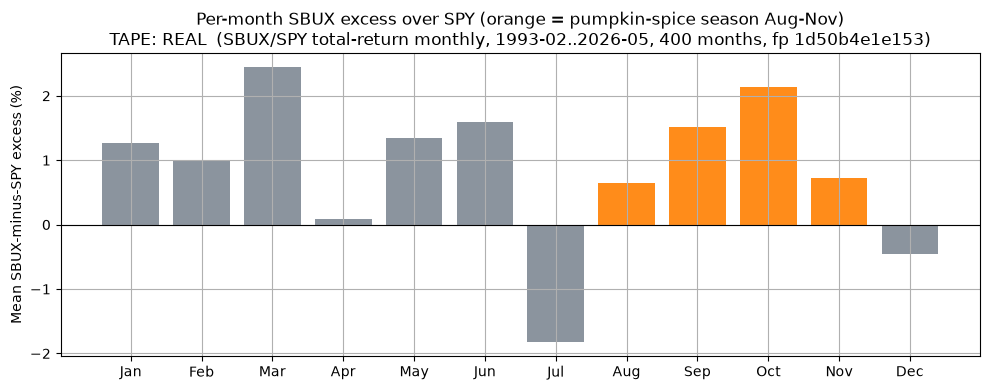

Season Aug-Nov: +1.25%/mo  (n=132)
Off-season:     +0.69%/mo  (n=268)
Season - Off spread: +0.56%  Welch t=0.65


In [2]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
means = [ms.loc[m,'mean']*100 for m in range(1,13)]
tstats = [ms.loc[m,'tstat'] for m in range(1,13)]
season=[8,9,10,11]
colors = ['#c0392b' if abs(tstats[m-1])>=2 else ('#ff8c1a' if m in season else '#8b949e') for m in range(1,13)]
fig,ax = plt.subplots(figsize=(10,4))
ax.bar(month_names, means, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean SBUX-minus-SPY excess (%)')
ax.set_title(f'Per-month SBUX excess over SPY (orange = pumpkin-spice season Aug-Nov)\nTAPE: {TAPE}')
plt.tight_layout(); plt.show()
print(f"Season Aug-Nov: {se['season_mean']*100:+.2f}%/mo  (n={se['n_season']})")
print(f"Off-season:     {se['off_mean']*100:+.2f}%/mo  (n={se['n_off']})")
print(f"Season - Off spread: {se['spread']*100:+.2f}%  Welch t={se['tstat']:.2f}")

## 4 · The teardown — let's actually look

Look at the orange (pumpkin-spice) bars. They're not taller than the grey ones — and August, the launch month everyone points to, is one of the *smallest*. The season-minus-off spread is **+0.56%/month with t = 0.65**: indistinguishable from zero, with a confidence interval running **−0.84% to +1.92%**. SBUX beats the market in plenty of months; it just doesn't do it *especially* when the pumpkin drinks are out.

In [3]:
wp = st.window_placebo(excess)
disp = wp.copy(); disp['spread'] = (disp['spread']*100).round(2)
disp['label'] = np.where(disp['is_psl'], disp['months']+'  <-- PSL', disp['months'])
print(f'TAPE: {TAPE}\n')
print('All twelve 4-month windows, excess spread vs rest-of-year (best first):')
for rk,row in disp.iterrows():
    print(f"  #{rk+1}: {row['label']:22s} spread {row['spread']:+.2f}%  t={row['tstat']:+.2f}")
psl_rank = int(wp[wp['is_psl']].index[0]) + 1
print(f'\nPumpkin-spice window (Aug-Nov) ranks #{psl_rank} of {len(wp)} -- an off-thesis window wins.')

TAPE: REAL  (SBUX/SPY total-return monthly, 1993-02..2026-05, 400 months, fp 1d50b4e1e153)

All twelve 4-month windows, excess spread vs rest-of-year (best first):
  #1: Mar-Apr-May-Jun        spread +0.74%  t=+0.79
  #2: Aug-Sep-Oct-Nov  <-- PSL spread +0.56%  t=+0.65
  #3: Feb-Mar-Apr-May        spread +0.53%  t=+0.58
  #4: Jan-Feb-Mar-Apr        spread +0.49%  t=+0.51
  #5: Dec-Jan-Feb-Mar        spread +0.30%  t=+0.33
  #6: Sep-Oct-Nov-Dec        spread +0.15%  t=+0.18
  #7: Oct-Nov-Dec-Jan        spread +0.06%  t=+0.06
  #8: Nov-Dec-Jan-Feb        spread -0.36%  t=-0.40
  #9: Jul-Aug-Sep-Oct        spread -0.39%  t=-0.42
  #10: Jun-Jul-Aug-Sep        spread -0.59%  t=-0.64
  #11: May-Jun-Jul-Aug        spread -0.65%  t=-0.70
  #12: Apr-May-Jun-Jul        spread -0.86%  t=-0.88

Pumpkin-spice window (Aug-Nov) ranks #2 of 12 -- an off-thesis window wins.


**Read it plainly.** If pumpkin-spice season were a real market edge, the Aug–Nov window would sit at the top of that list. It's #2 — beaten by a spring window (Mar–Jun) that has nothing to do with pumpkins. The "season" is a story we drew around one ordinary quarter of a great stock's year.

In [4]:
res = {
    'seasonal rotation (long SBUX Aug-Nov, else SPY)': st.summary(rot, rf=rf),
    'rotation net 5bp':                                st.summary(rot_net, rf=rf),
    'buy & hold SPY':                                  st.summary(bh_spy, rf=rf),
    'buy & hold SBUX':                                 st.summary(bh_sbux, rf=rf),
}
display(pd.DataFrame(res).T[['cagr','sharpe','max_drawdown']].round(3))
print('Sharpe = excess of T-bill; the rotation only *looks* to edge SPY because it borrows')
print('SBUX beta for 4 months -- and a DIFFERENT 4 months (Mar-Jun) would have been better.')

,cagr,sharpe,max_drawdown
"seasonal rotation (long SBUX Aug-Nov, else SPY)",0.151,0.659,-0.635
rotation net 5bp,0.150,0.654,-0.636
buy & hold SPY,0.109,0.610,-0.508
buy & hold SBUX,0.176,0.582,-0.764


Sharpe = excess of T-bill; the rotation only *looks* to edge SPY because it borrows
SBUX beta for 4 months -- and a DIFFERENT 4 months (Mar-Jun) would have been better.


## 5 · The verdict

**Signal: None** — the season-vs-off excess spread is t = 0.65 with a CI that straddles zero; no month clears |t| ≥ 2, and the PSL window isn't even the best 4-month slice. **Tradability: Mirage** — the market-neutral "be in the pair only for the season" trade earns Sharpe 0.27, *less* than just holding the SBUX-vs-SPY pair all year (0.35). The season *dilutes* the edge, it doesn't concentrate it. **"Pumpkin premium"? Busted** — the spread is *negative* in 1993–2009 and only turns up in a snooped 2010-on half.

## 6 · Could you actually trade it?

Not as a *seasonal* edge. The long-only rotation's headline Sharpe (0.66 vs SPY's 0.61) is a magic trick: it substitutes a higher-returning stock into four months of the year. But (a) you had to *know in advance* that SBUX would be a 30-year winner (survivorship — most "buy the beloved brand" bets don't end up as Starbucks), and (b) the pumpkin months aren't even the right four. Strip out the borrowed SBUX beta and the pure seasonal signal is worth nothing.

## 7 · Going further 🚪

Forks: (a) test the calendar on **fundamentals** — do SBUX's autumn-quarter same-store sales actually beat its other quarters, or is even *that* a myth? (b) a **QSR-basket** version (SBUX/MCD/YUM/CMG) to see if any "autumn consumer" pop is broader than one name (spoiler in the quants notebook: t = 0.71); (c) compare to [307 Coffee-Seasonality](../../307-coffee-seasonality/) — the *commodity* calendar behind the cup, another None/Mirage.